# KNN

In [3]:
import sys 
sys.path.append("..")
from src.models.KNN.knn_model import run_knn_pipeline, plot_k_selection, plot_knn_roc
import pandas as pd
from sklearn.model_selection import train_test_split

,model,split,k,accuracy,precision,recall,f1,roc_auc
0,KNN,train,13,0.849372,0.815385,0.688312,0.746479,0.931177


,model,split,k,accuracy,precision,recall,f1,roc_auc
0,KNN,test,13,0.766667,0.692308,0.473684,0.5625,0.89923


,k,accuracy,precision,recall,f1,roc_auc
0,13,0.766667,0.692308,0.473684,0.562500,0.899230
1,15,0.783333,0.750000,0.473684,0.580645,0.897946
2,11,0.750000,0.642857,0.473684,0.545455,0.888960
3,5,0.783333,0.687500,0.578947,0.628571,0.874198
4,3,0.800000,0.684211,0.684211,0.684211,0.872272
5,7,0.766667,0.666667,0.526316,0.588235,0.865212
6,9,0.750000,0.642857,0.473684,0.545455,0.858793


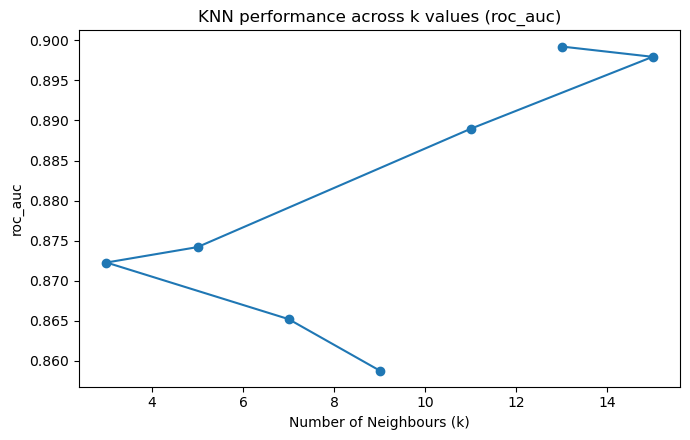

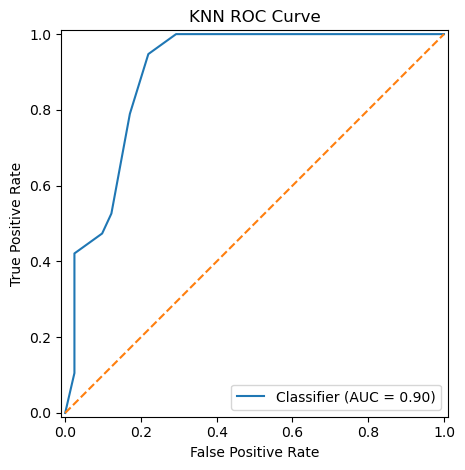

In [5]:
df = pd.read_csv("../data/processed/heart_failure_clinical_records_dataset_processed.csv")

selected_features = [
    "time",
    "age_centered",
    "ejection_fraction_centered",
    "sodium_creatinine_interaction",
]

X = df[selected_features]
y = df["DEATH_EVENT"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

results = run_knn_pipeline(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

display(results["train_metrics_df"])
display(results["test_metrics_df"])

results["test_metrics"]["confusion_matrix"]
display(results["k_search_results"]["results_table"])
plot_k_selection(results["k_search_results"]["results_table"], metric="roc_auc")

plot_knn_roc(
    y_test,
    results["y_proba_test"]
)
